In [1]:
import numpy as np
import pandas as pd

In [2]:
EM=pd.read_csv("C:\\Users\\DELL User\\Desktop\\MINNING\\Energy_Data_Restructured.csv")
EM

,Year,Period,Energy Source,Consumption,Unit,GJ Equivalent,tCO?e
0,2023,Jan,Electricity,"12,349.65",MWh,"44,458.40","8,336.02"
1,2023,Jan,Diesel,"1,564,339.90",Litres,"56,532.53","4,221.84"
2,2023,Jan,LPG,"128,548.50",Litres,"3,267.18",209.00
3,2023,Feb,Electricity,"10,702.81",MWh,"38,529.79","7,224.39"
4,2023,Feb,Diesel,"1,411,110.97",Litres,"50,995.10","3,808.31"
...,...,...,...,...,...,...,...
103,2025,Nov,Diesel,"1,941,270.96",Litres,"70,154.17","5,166.79"
104,2025,Nov,LPG,"104,163.00",Litres,"2,220.79",142.01
105,2025,Dec,Electricity,"9,339.14",MWh,"33,620.62","6,426.17"
106,2025,Dec,Diesel,"2,162,019.16",Litres,"78,131.62","5,754.32"


In [3]:
EM.describe()

,Year
count,108.000000
mean,2024.000000
std,0.820303
min,2023.000000
25%,2023.000000
50%,2024.000000
75%,2025.000000
max,2025.000000


CONVERTING COLUMS TO NUMERIC

In [4]:
cols = ['Consumption',
        'GJ Equivalent',
        'tCO?e']

for col in cols:
    EM[col] = EM[col].str.replace(',', '').astype(float)

In [5]:
EM

,Year,Period,Energy Source,Consumption,Unit,GJ Equivalent,tCO?e
0,2023,Jan,Electricity,12349.65,MWh,44458.40,8336.02
1,2023,Jan,Diesel,1564339.90,Litres,56532.53,4221.84
2,2023,Jan,LPG,128548.50,Litres,3267.18,209.00
3,2023,Feb,Electricity,10702.81,MWh,38529.79,7224.39
4,2023,Feb,Diesel,1411110.97,Litres,50995.10,3808.31
...,...,...,...,...,...,...,...
103,2025,Nov,Diesel,1941270.96,Litres,70154.17,5166.79
104,2025,Nov,LPG,104163.00,Litres,2220.79,142.01
105,2025,Dec,Electricity,9339.14,MWh,33620.62,6426.17
106,2025,Dec,Diesel,2162019.16,Litres,78131.62,5754.32


In [6]:
EM.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           108 non-null    int64  
 1   Period         108 non-null    object 
 2   Energy Source  108 non-null    object 
 3   Consumption    108 non-null    float64
 4   Unit           108 non-null    object 
 5   GJ Equivalent  108 non-null    float64
 6   tCO?e          108 non-null    float64
dtypes: float64(3), int64(1), object(3)
memory usage: 6.0+ KB


SUMMARY STATISTICS

In [7]:
EM.describe()

,Year,Consumption,GJ Equivalent,tCO?e
count,108.000000,1.080000e+02,108.000000,108.000000
mean,2024.000000,4.162973e+05,28118.564074,3641.773796
std,0.820303,5.814228e+05,20953.823502,3246.523085
min,2023.000000,9.339140e+03,1722.580000,110.150000
25%,2023.000000,1.183880e+04,3867.475000,247.395000
50%,2024.000000,1.368502e+05,38782.005000,3165.875000
75%,2025.000000,5.699027e+05,42589.825000,7608.230000
max,2025.000000,2.162019e+06,78131.620000,8414.820000


Group MEANS

In [8]:
Energymeans=EM.groupby('Energy Source')[['GJ Equivalent','tCO?e']].describe()
#Energymeans = EM.groupby('Energy Source').agg({
  #  'GJ Equivalent':['mean','std','min','max'],
  #  'tCO?e':['mean','std','min','max']
#}).round(2)
Energymeans = Energymeans.round(2)
Energymeans

GJ Equivalent                                                    \
                      count      mean       std       min       25%       50%   
Energy Source                                                                   
Diesel                 36.0  39861.38  19718.73   9218.99  21163.44  42684.42   
Electricity            36.0  41156.91   2133.51  33620.62  40397.74  41200.37   
LPG                    36.0   3337.40    746.02   1722.58   2877.10   3349.54   

                                  tCO?e                                      \
                    75%       max count     mean      std      min      25%   
Energy Source                                                                 
Diesel         55215.65  78131.62  36.0  2964.56  1464.78   678.97  1580.48   
Electricity    42589.82  44458.40  36.0  7747.30   420.04  6426.17  7620.87   
LPG             3864.76   5232.10  36.0   213.47    47.72   110.15   183.98   

                                          
                   50%      75%      max  
Energy Source                             
Diesel         3165.88  4123.49  5754.32  
Electricity    7799.03  7997.59  8414.82  
LPG             214.26   247.22   334.58

In [9]:


writer = pd.ExcelWriter(
    'Mining_Analysis_Tables.xlsx',
    engine='openpyxl'
)

Energymeans.to_excel(
    writer,
    sheet_name='Summary Statistics'
)
writer.close()

In [10]:
# from docx import Document
# doc = Document()
# doc.add_heading(
#     'Impact of Energy Consumption on Carbon Emissions in Mining Operations',
#     level=1
# )
# doc.add_paragraph(
#     'Damang Gold Mining Limited Analysis Report'
# )

# doc.add_heading('1. Summary Statistics', level=1)
# Energymeans_reset = Energymeans.reset_index()
# table = doc.add_table(
#     rows=1,
#     cols=len(Energymeans_reset.columns)
# )
# for _, row in Energymeans_reset.iterrows():

#     row_cells = table.add_row().cells

#     for i, value in enumerate(row):
#         row_cells[i].text = str(value)

# doc.add_paragraph(
#     'The summary statistics provide an overview of '
#     'energy consumption and carbon emissions across '
#     'the different energy sources used in mining operations.'
# )

# doc.save('Mining_Emissions_Report.docx')

In [11]:
EM['Emission_Intensity'] = EM['tCO?e'] / EM['GJ Equivalent']
EM.head()

,Year,Period,Energy Source,Consumption,Unit,GJ Equivalent,tCO?e,Emission_Intensity
0,2023,Jan,Electricity,12349.65,MWh,44458.40,8336.02,0.187502
1,2023,Jan,Diesel,1564339.90,Litres,56532.53,4221.84,0.074680
2,2023,Jan,LPG,128548.50,Litres,3267.18,209.00,0.063970
3,2023,Feb,Electricity,10702.81,MWh,38529.79,7224.39,0.187501
4,2023,Feb,Diesel,1411110.97,Litres,50995.10,3808.31,0.074680


In [12]:

Energymeans=EM.groupby('Energy Source')[['GJ Equivalent','tCO?e','Emission_Intensity']].describe()
Energymeans

GJ Equivalent                                                   \
                      count          mean           std       min        25%   
Energy Source                                                                  
Diesel                 36.0  39861.377500  19718.728166   9218.99  21163.445   
Electricity            36.0  41156.910278   2133.507722  33620.62  40397.735   
LPG                    36.0   3337.404444    746.022018   1722.58   2877.100   

                                               tCO?e               ...  \
                     50%         75%       max count         mean  ...   
Energy Source                                                      ...   
Diesel         42684.425  55215.6525  78131.62  36.0  2964.557778  ...   
Electricity    41200.365  42589.8250  44458.40  36.0  7747.297222  ...   
LPG             3349.535   3864.7650   5232.10  36.0   213.466389  ...   

                                  Emission_Intensity                      \
                     75%      max              count      mean       std   
Energy Source                                                              
Diesel         4123.4925  5754.32               36.0  0.074336  0.000493   
Electricity    7997.5900  8414.82               36.0  0.188226  0.002270   
LPG             247.2250   334.58               36.0  0.063961  0.000011   

                                                                 
                    min       25%       50%       75%       max  
Energy Source                                                    
Diesel         0.073649  0.073649  0.074680  0.074680  0.074680  
Electricity    0.178329  0.187501  0.187502  0.190504  0.191138  
LPG            0.063945  0.063946  0.063968  0.063969  0.063970  

[3 rows x 24 columns]

In [13]:

Annualenergymeans=EM.groupby(["Year","Energy Source"])[['GJ Equivalent','tCO?e','Emission_Intensity']].describe()
Annualenergymeans

GJ Equivalent                                        \
                           count          mean           std       min   
Year Energy Source                                                       
2023 Diesel                 12.0  44172.343333   8025.131925  30649.85   
     Electricity            12.0  41224.353333   1815.079005  38452.59   
     LPG                    12.0   3487.140000    480.044668   2446.98   
2024 Diesel                 12.0  39659.761667  22105.115418  10902.13   
     Electricity            12.0  42050.834167   1177.624563  40285.25   
     LPG                    12.0   3488.795000    716.568472   1854.95   
2025 Diesel                 12.0  35752.027500  25404.757702   9218.99   
     Electricity            12.0  40195.543333   2813.700377  33620.62   
     LPG                    12.0   3036.278333    937.305748   1722.58   

                                                                tCO?e  \
                           25%        50%         75%       max count   
Year Energy Source                                                      
2023 Diesel         38854.3300  43458.735  51466.9775  56532.53  12.0   
     Electricity    40275.2525  41425.275  42282.5225  44458.40  12.0   
     LPG             3224.3950   3525.180   3828.6675   4174.98  12.0   
2024 Diesel         18674.0400  48897.510  56331.1600  70050.87  12.0   
     Electricity    41131.6800  42054.030  42790.2700  43990.39  12.0   
     LPG             2979.0200   3709.445   3950.5000   4438.83  12.0   
2025 Diesel         11925.6125  31284.205  57671.4275  78131.62  12.0   
     Electricity    39328.4875  40681.915  41730.8625  44039.75  12.0   
     LPG             2661.3175   2877.100   3213.0775   5232.10  12.0   

                                 ...                     Emission_Intensity  \
                           mean  ...        75%      max              count   
Year Energy Source               ...                                          
2023 Diesel         3298.784167  ...  3843.5475  4221.84               12.0   
     Electricity    7729.627500  ...  7928.0325  8336.02               12.0   
     LPG             223.067500  ...   244.9150   267.07               12.0   
2024 Diesel         2961.785833  ...  4206.8025  5231.39               12.0   
     Electricity    7884.595000  ...  8023.2400  8248.26               12.0   
     LPG             223.173333  ...   252.7100   283.95               12.0   
2025 Diesel         2633.103333  ...  4247.4500  5754.32               12.0   
     Electricity    7627.669167  ...  7955.0650  8414.82               12.0   
     LPG             194.158333  ...   205.4650   334.58               12.0   

                                                                          \
                        mean           std       min       25%       50%   
Year Energy Source                                                         
2023 Diesel         0.074680  7.767773e-08  0.074680  0.074680  0.074680   
     Electricity    0.187501  8.071870e-08  0.187501  0.187501  0.187501   
     LPG            0.063969  6.129580e-07  0.063968  0.063968  0.063969   
2024 Diesel         0.074680  1.015446e-07  0.074680  0.074680  0.074680   
     Electricity    0.187502  7.821346e-08  0.187501  0.187501  0.187502   
     LPG            0.063969  9.873989e-07  0.063967  0.063968  0.063969   
2025 Diesel         0.073649  1.747678e-07  0.073649  0.073649  0.073649   
     Electricity    0.189676  3.599435e-03  0.178329  0.190517  0.190793   
     LPG            0.063946  7.171449e-07  0.063945  0.063946  0.063946   

                                        
                         75%       max  
Year Energy Source                      
2023 Diesel         0.074680  0.074680  
     Electricity    0.187502  0.187502  
     LPG            0.063969  0.063970  
2024 Diesel         0.074680  0.074680  
     Electricity    0.187502  0.187502  
     LPG            0.063969  0.063970  
2025 Diesel         0.

EXPLORATORY DATA ANALYSIS

In [14]:
MONTH_ORDER = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"] ## the month ordering


EM["Period"] = pd.Categorical(EM["Period"], categories=MONTH_ORDER, ordered=True)## the sequence and order matters
EM = EM.sort_values(["Year", "Period"]).reset_index(drop=True)

In [15]:
EM

,Year,Period,Energy Source,Consumption,Unit,GJ Equivalent,tCO?e,Emission_Intensity
0,2023,Jan,Electricity,12349.65,MWh,44458.40,8336.02,0.187502
1,2023,Jan,Diesel,1564339.90,Litres,56532.53,4221.84,0.074680
2,2023,Jan,LPG,128548.50,Litres,3267.18,209.00,0.063970
3,2023,Feb,Electricity,10702.81,MWh,38529.79,7224.39,0.187501
4,2023,Feb,Diesel,1411110.97,Litres,50995.10,3808.31,0.074680
...,...,...,...,...,...,...,...,...
103,2025,Nov,Diesel,1941270.96,Litres,70154.17,5166.79,0.073649
104,2025,Nov,LPG,104163.00,Litres,2220.79,142.01,0.063946
105,2025,Dec,Electricity,9339.14,MWh,33620.62,6426.17,0.191138
106,2025,Dec,Diesel,2162019.16,Litres,78131.62,5754.32,0.073649


C:\Users\DELL User\AppData\Local\Temp\ipykernel_7916\1245462685.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  EM.groupby('Period')['Emission_Intensity'].mean().plot()


<Axes: xlabel='Period'>

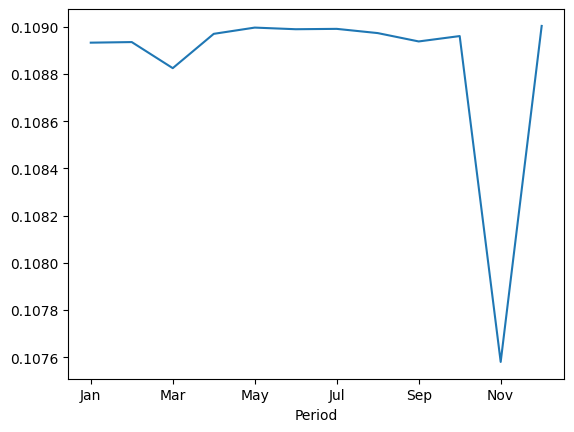

In [16]:
EM.groupby('Period')['Emission_Intensity'].mean().plot()

ANNUAL TOTALS

In [17]:
print(" Annual Totals")
annual = EM.groupby(["Year","Energy Source"])[["GJ Equivalent","tCO?e"]].sum()
annual

 Annual Totals


GJ Equivalent     tCO?e
Year Energy Source                         
2023 Diesel             530068.12  39585.41
     Electricity        494692.24  92755.53
     LPG                 41845.68   2676.81
2024 Diesel             475917.14  35541.43
     Electricity        504610.01  94615.14
     LPG                 41865.54   2678.08
2025 Diesel             429024.33  31597.24
     Electricity        482346.52  91532.03
     LPG                 36435.34   2329.90

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

ValueError: not enough values to unpack (expected at least 1, got 0)

total energy consumption over time, and total carbon emmision over time... after we do energy source conttibution. and emmission by energy source total impact. 

In [19]:
EM["Period"] = pd.Categorical(EM["Period"], categories=MONTH_ORDER, ordered=True)
EM = EM.sort_values(["Year", "Period"]).reset_index(drop=True)

For each Year+Month combo, this adds up GJ from Electricity + Diesel + LPG into a single number. observed=True is needed because Period is now a Categorical column.

In [20]:
monthly_total = EM.groupby(["Year", "Period"], observed=True)["GJ Equivalent"].sum().reset_index()
monthly_total

,Year,Period,GJ Equivalent
0,2023,Jan,104258.11
1,2023,Feb,91971.87
2,2023,Mar,99089.89
3,2023,Apr,99313.08
4,2023,May,90182.60
5,2023,Jun,88335.53
6,2023,Jul,86576.59
7,2023,Aug,76657.73
8,2023,Sep,78219.67
9,2023,Oct,84168.38


The below code  creates a combined column like "Jan 2023" that we'll use as the x-axis labels on the chart. Tell me what you see after running it!

In [21]:
monthly_total["Label"] = monthly_total["Period"].astype(str) + " " + monthly_total["Year"].astype(str)
monthly_total

,Year,Period,GJ Equivalent,Label
0,2023,Jan,104258.11,Jan 2023
1,2023,Feb,91971.87,Feb 2023
2,2023,Mar,99089.89,Mar 2023
3,2023,Apr,99313.08,Apr 2023
4,2023,May,90182.60,May 2023
5,2023,Jun,88335.53,Jun 2023
6,2023,Jul,86576.59,Jul 2023
7,2023,Aug,76657.73,Aug 2023
8,2023,Sep,78219.67,Sep 2023
9,2023,Oct,84168.38,Oct 2023


TOTAL ENERGY CONTRIBUTION OVER TIME

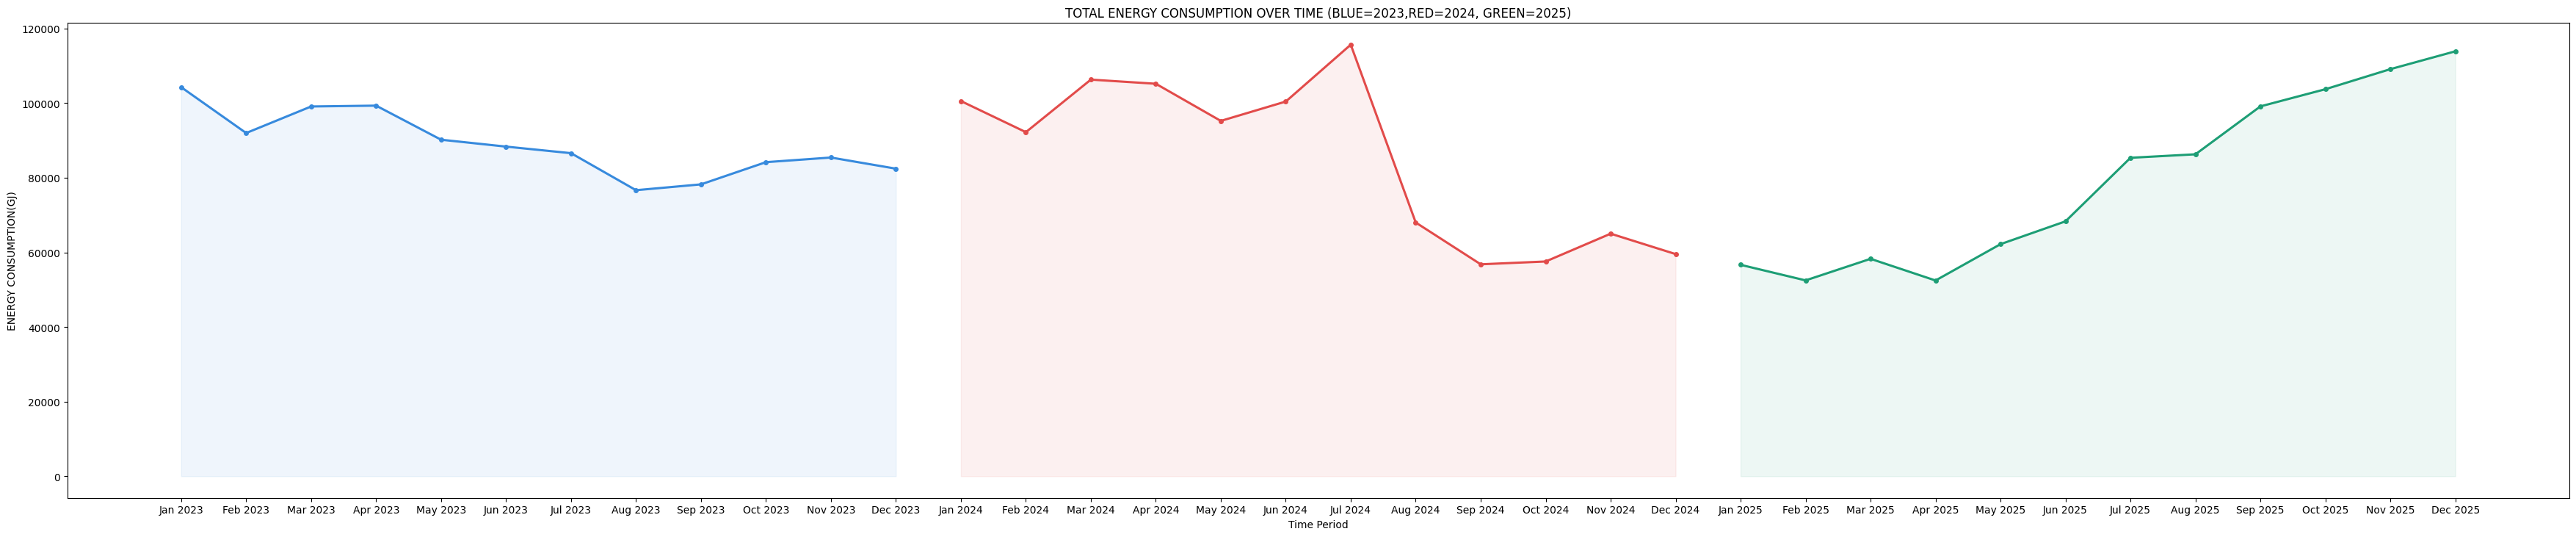

In [22]:
YEAR_COLORS = {2023: "#378ADD", 2024: "#E24B4A", 2025: "#1D9E75"}

fig, ax = plt.subplots(figsize=(35,7))

for year, grp in monthly_total.groupby("Year"):
    ax.plot(grp["Label"], grp["GJ Equivalent"],
            color=YEAR_COLORS[year], linewidth=2.2,
            marker="o", markersize=4, label=str(year))
    ax.fill_between(grp["Label"], grp["GJ Equivalent"],
                    alpha=0.08, color=YEAR_COLORS[year])


plt.tight_layout()
plt.ylabel('ENERGY CONSUMPTION(GJ)')
plt.xlabel('Time Period')
plt.title('TOTAL ENERGY CONSUMPTION OVER TIME (BLUE=2023,RED=2024, GREEN=2025)')
plt.show()

# plt.savefig(
#     'total_energy_consumption.png',
#     dpi=300,
#     bbox_inches='tight'
# )

# plt.show()

In [23]:
from docx.shared import Inches

In [24]:
# doc = Document('Mining_Emissions_Report.docx')
# doc.add_picture(
#     'total_energy_consumption.png',
#     width=Inches(7)
# )
# doc.add_paragraph(
#     'The figure illustrates fluctuations in total '
#     'energy consumption across the study period. '
#     'Energy usage patterns varied across the years, '
#     'with noticeable operational changes observed '
#     'between 2023 and 2025.'
# )
# doc.save('Mining_Emissions_Report.docx')

TOTAL CARBRBORN EMMISSION OVER TIME

In [25]:
monthly_totalE = EM.groupby(["Year", "Period"], observed=True)["tCO?e"].sum().reset_index()
#monthly_totalE

In [26]:
monthly_totalE['lable']=monthly_totalE['Period'].astype(str)+ " " +monthly_totalE['Year'].astype(str)
#monthly_totalE

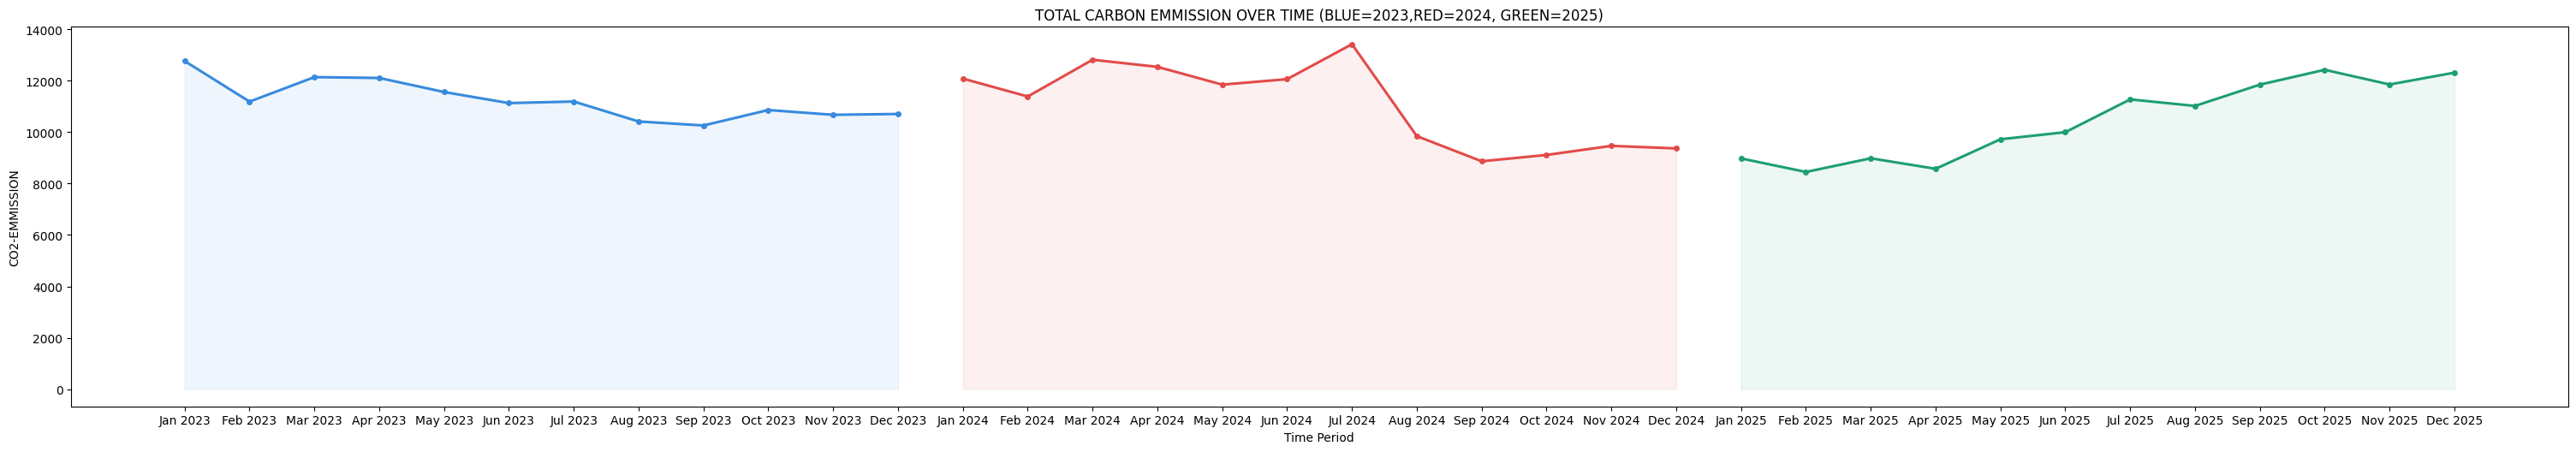

In [27]:
YEAR_COLORS = {2023: "#378ADD", 2024: "#E24B4A", 2025: "#1D9E75"}
fig, ax = plt.subplots(figsize=(30,5))## blank space and area

for year, grp in monthly_totalE.groupby("Year"): ##grouping my data by the years so 3 years.. so like for x and y in monthly data groub them in 3 different years
    ax.plot(grp["lable"], grp["tCO?e"],
        color=YEAR_COLORS[year], linewidth=2.2,
        marker="o", markersize=4, label=str(year))
    

    ## shaded area 
    ax.fill_between(grp["lable"], grp["tCO?e"],
                alpha=0.08, color=YEAR_COLORS[year])
    

plt.tight_layout()
plt.ylabel('CO2-EMMISSION')
plt.xlabel('Time Period')
plt.title('TOTAL CARBON EMMISSION OVER TIME (BLUE=2023,RED=2024, GREEN=2025)')
plt.show()
#“Exploratory trend analysis revealed fluctuating carbon emission patterns across the study period. Emissions in 2023 generally declined from January toward December, while 2024 exhibited relatively high but unstable emissions in the first half before declining sharply after July. In contrast, emissions in 2025 showed a persistent upward trend throughout the year. These patterns suggest varying operational intensity and potential structural changes in energy utilization within the mining operations.”

In [28]:
EM

,Year,Period,Energy Source,Consumption,Unit,GJ Equivalent,tCO?e,Emission_Intensity
0,2023,Jan,Electricity,12349.65,MWh,44458.40,8336.02,0.187502
1,2023,Jan,Diesel,1564339.90,Litres,56532.53,4221.84,0.074680
2,2023,Jan,LPG,128548.50,Litres,3267.18,209.00,0.063970
3,2023,Feb,Electricity,10702.81,MWh,38529.79,7224.39,0.187501
4,2023,Feb,Diesel,1411110.97,Litres,50995.10,3808.31,0.074680
...,...,...,...,...,...,...,...,...
103,2025,Nov,Diesel,1941270.96,Litres,70154.17,5166.79,0.073649
104,2025,Nov,LPG,104163.00,Litres,2220.79,142.01,0.063946
105,2025,Dec,Electricity,9339.14,MWh,33620.62,6426.17,0.191138
106,2025,Dec,Diesel,2162019.16,Litres,78131.62,5754.32,0.073649


TOTAL CONTRIBUTION BY SOURCE

C:\Users\DELL User\AppData\Local\Temp\ipykernel_7916\2945658936.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  energy_pivot = EM.pivot_table(


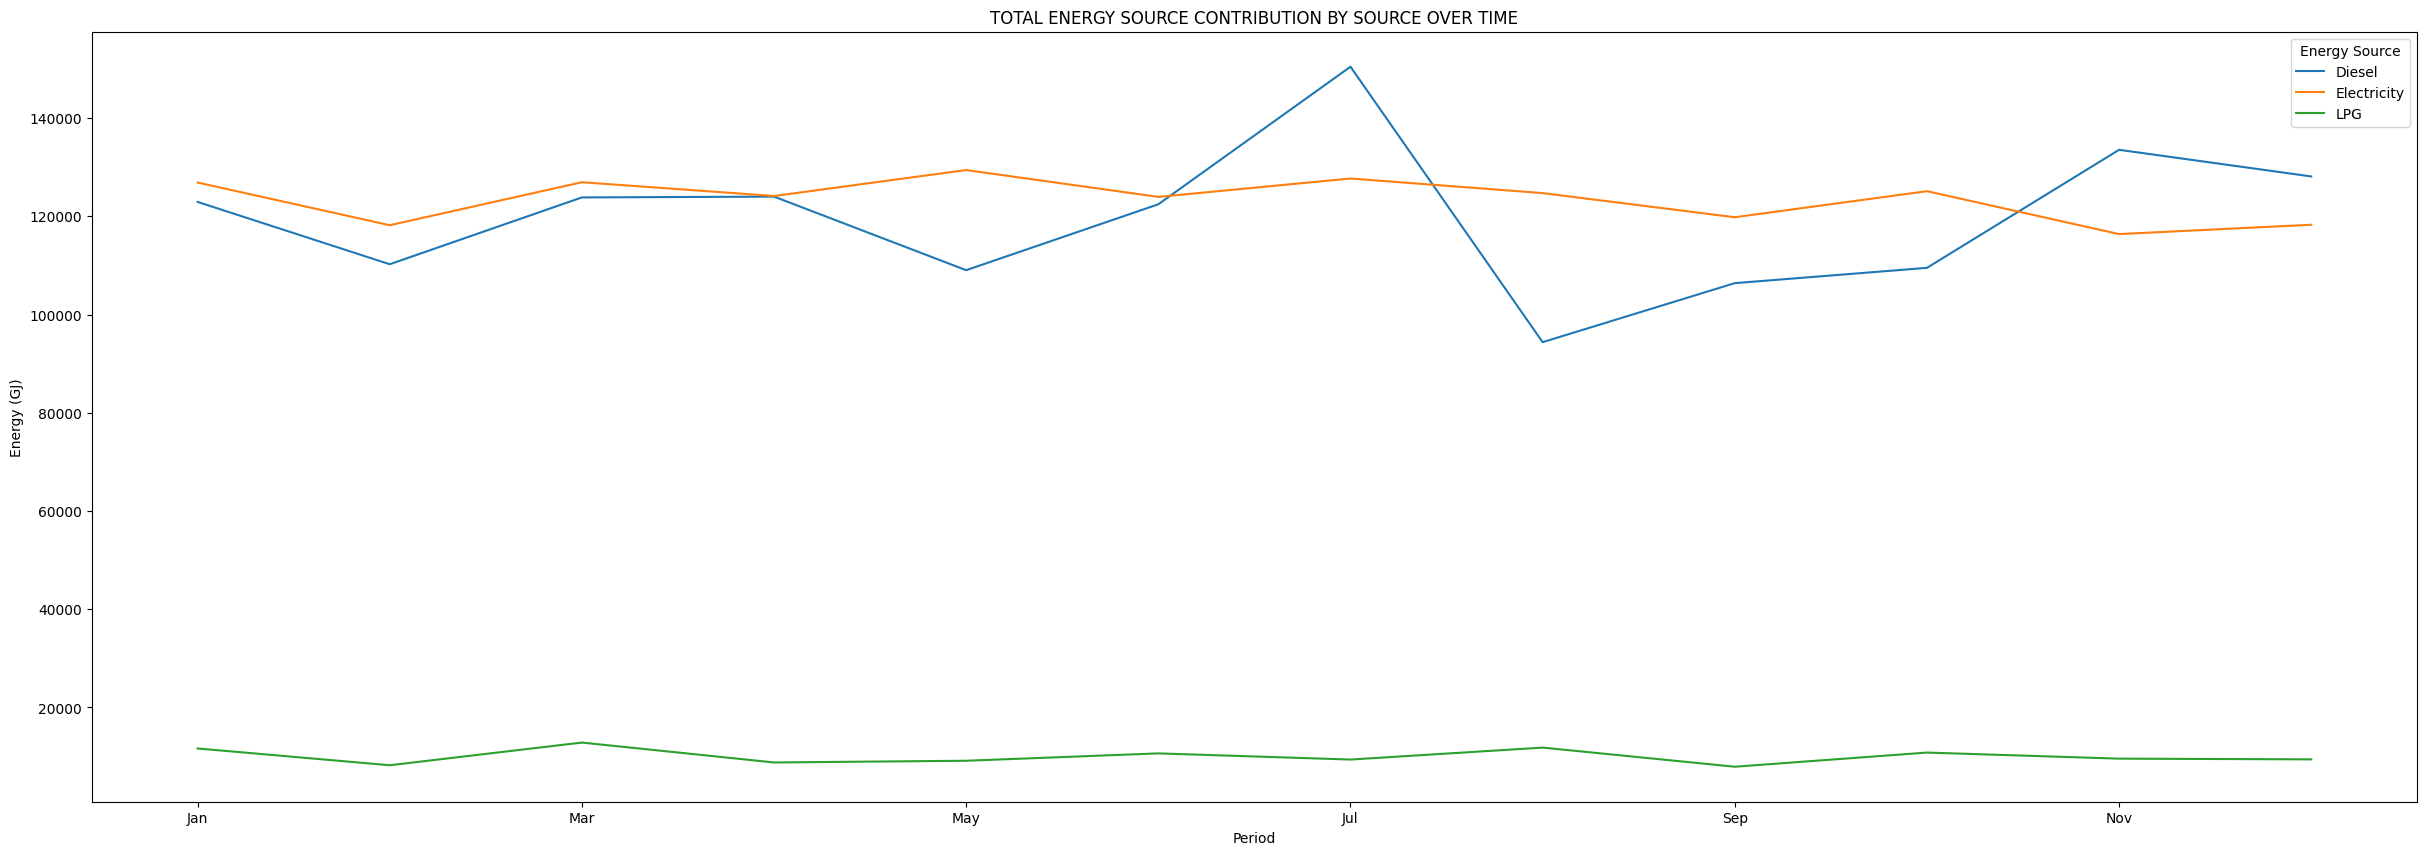

In [29]:
energy_pivot = EM.pivot_table(
    values='GJ Equivalent',
    index='Period',
    columns='Energy Source',
    aggfunc='sum'
)

energy_pivot.plot(figsize=(30,10))

plt.title('TOTAL ENERGY SOURCE CONTRIBUTION BY SOURCE OVER TIME')
plt.ylabel('Energy (GJ)')
plt.show()

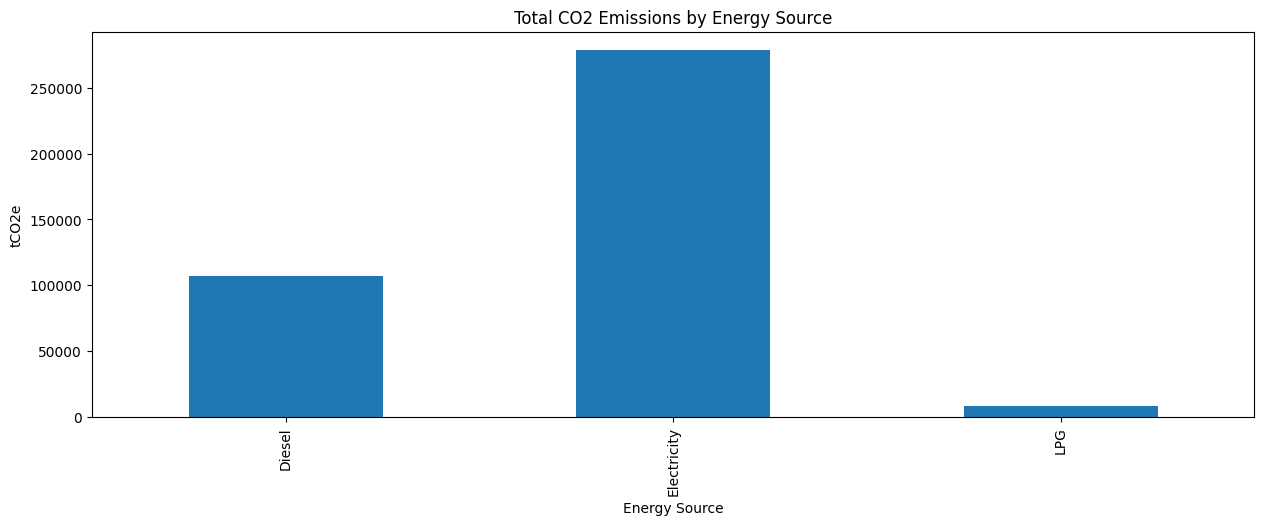

In [30]:
EM.groupby('Energy Source')['tCO?e'].sum().plot(kind='bar',figsize=(15,5))

plt.title('Total CO2 Emissions by Energy Source')
plt.ylabel('tCO2e')
plt.show()

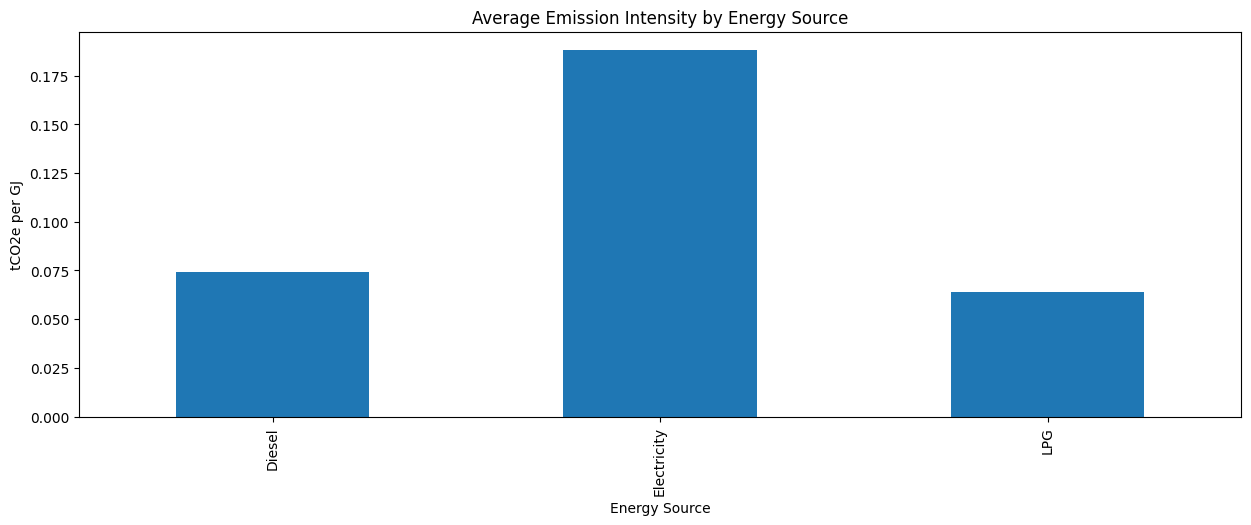

In [31]:
EM.groupby('Energy Source')['Emission_Intensity'].mean().plot(kind='bar',figsize=(15,5))
plt.title('Average Emission Intensity by Energy Source')
plt.ylabel('tCO2e per GJ')
plt.show()

SCATTER PLOT RELATIONSHIPS: ENERGY CONTRIBUTION VS EMISSIONS

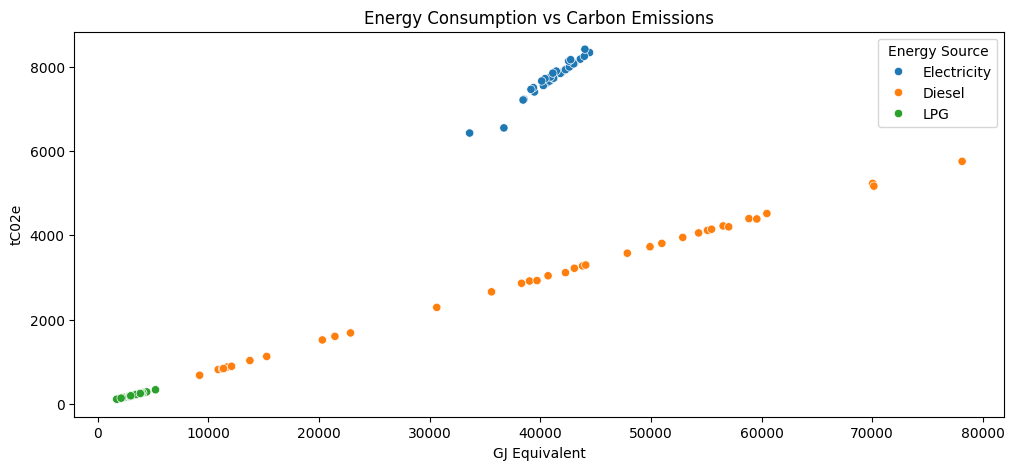

In [32]:
plt.figure(figsize=(12,5))
sns.scatterplot(
    data=EM,
    x='GJ Equivalent',
    y='tCO?e',
    hue='Energy Source'
)

plt.title('Energy Consumption vs Carbon Emissions')
plt.ylabel('tC02e')
plt.show() ###Strong upward pattern = emissions driven by energy use

HEAT MAP CORRECAATION

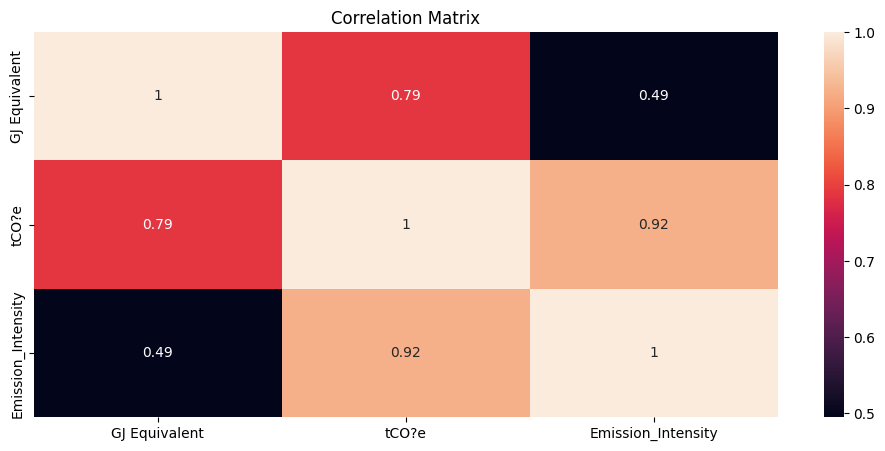

In [33]:

plt.figure(figsize=(12,5))
corr = EM[['GJ Equivalent','tCO?e','Emission_Intensity']].corr()

sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()
figsize=(20,15)

REGRESSION 

In [34]:
EM

,Year,Period,Energy Source,Consumption,Unit,GJ Equivalent,tCO?e,Emission_Intensity
0,2023,Jan,Electricity,12349.65,MWh,44458.40,8336.02,0.187502
1,2023,Jan,Diesel,1564339.90,Litres,56532.53,4221.84,0.074680
2,2023,Jan,LPG,128548.50,Litres,3267.18,209.00,0.063970
3,2023,Feb,Electricity,10702.81,MWh,38529.79,7224.39,0.187501
4,2023,Feb,Diesel,1411110.97,Litres,50995.10,3808.31,0.074680
...,...,...,...,...,...,...,...,...
103,2025,Nov,Diesel,1941270.96,Litres,70154.17,5166.79,0.073649
104,2025,Nov,LPG,104163.00,Litres,2220.79,142.01,0.063946
105,2025,Dec,Electricity,9339.14,MWh,33620.62,6426.17,0.191138
106,2025,Dec,Diesel,2162019.16,Litres,78131.62,5754.32,0.073649


In [35]:
electricity_jan = EM[
    (EM["Energy Source"] == "Electricity") & 
    (EM["Period"] == "Jan")
]["GJ Equivalent"].sum()

print(electricity_jan)

126889.38999999998


In [36]:
#Regression expects ONE ROW = ONE OBSERVATION, so we creat Pivot so each energy source becomes its own energy contribution column


reg_EM = EM.pivot_table(
    index='Period',
    columns='Energy Source',
    values='GJ Equivalent',
    
    aggfunc='sum'
)
reg_EM 

C:\Users\DELL User\AppData\Local\Temp\ipykernel_7916\702838404.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  reg_EM = EM.pivot_table(


Energy Source,Diesel,Electricity,LPG
Period,,,
Jan,122940.09,126889.39,11635.60
Feb,110249.21,118197.86,8221.40
Mar,123854.52,126948.90,12839.10
Apr,124021.09,124145.29,8786.11
May,109038.82,129431.44,9135.51
Jun,122459.19,123961.94,10634.40
Jul,150473.59,127709.85,9379.10
Aug,94379.63,124738.10,11813.69
Sep,106397.71,119818.66,7919.12


In [37]:
janCarbon = EM[ 
    (EM["Period"] == "Jan")
]["tCO?e"].sum()

print(janCarbon)

33829.869999999995


In [38]:
# adding  Total Carbon Emissions
reg_EM['Total_tCO2e'] = EM.groupby('Period')['tCO?e'].sum()
reg_EM

C:\Users\DELL User\AppData\Local\Temp\ipykernel_7916\1304165492.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reg_EM['Total_tCO2e'] = EM.groupby('Period')['tCO?e'].sum()


Energy Source,Diesel,Electricity,LPG,Total_tCO2e
Period,,,,
Jan,122940.09,126889.39,11635.60,33829.87
Feb,110249.21,118197.86,8221.40,31028.79
Mar,123854.52,126948.90,12839.10,33944.07
Apr,124021.09,124145.29,8786.11,33226.59
May,109038.82,129431.44,9135.51,33137.46
Jun,122459.19,123961.94,10634.40,33194.27
Jul,150473.59,127709.85,9379.10,35892.78
Aug,94379.63,124738.10,11813.69,31283.80
Sep,106397.71,119818.66,7919.12,30978.85


In [39]:
#Defining regression Variables
X = reg_EM[['Electricity', 'Diesel', 'LPG']]
y = reg_EM['Total_tCO2e']

In [40]:
import statsmodels.api as sm

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())
##  Adj. R-squared: = 0.993 Interpretation: 99% of variations in carbon emissions are explained by energy consumption.
## Electricity and Diesel ar statistically significant given their p-values are less that 0.05.. LPG is not statistically significant

                            OLS Regression Results                            
Dep. Variable:            Total_tCO2e   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     494.1
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           2.04e-09
Time:                        22:08:06   Log-Likelihood:                -72.219
No. Observations:                  12   AIC:                             152.4
Df Residuals:                       8   BIC:                             154.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -2506.0082   1135.021     -2.208      

FORECASTING

In [41]:
EM["Period"] = pd.Categorical(EM["Period"], categories=MONTH_ORDER, ordered=True)
EM = EM.sort_values(["Year", "Period"]).reset_index(drop=True)

In [42]:

 
ts_E = EM.groupby(["Year", "Period"], observed=True)["tCO?e"].sum().reset_index()
ts_E['lable']=monthly_totalE['Period'].astype(str)+ " " +monthly_totalE['Year'].astype(str)
print(ts_E)

    Year Period     tCO?e     lable
0   2023    Jan  12766.86  Jan 2023
1   2023    Feb  11189.23  Feb 2023
2   2023    Mar  12141.88  Mar 2023
3   2023    Apr  12109.68  Apr 2023
4   2023    May  11562.89  May 2023
5   2023    Jun  11131.65  Jun 2023
6   2023    Jul  11193.03  Jul 2023
7   2023    Aug  10416.40  Aug 2023
8   2023    Sep  10260.93  Sep 2023
9   2023    Oct  10862.05  Oct 2023
10  2023    Nov  10675.10  Nov 2023
11  2023    Dec  10708.05  Dec 2023
12  2024    Jan  12084.80  Jan 2024
13  2024    Feb  11387.78  Feb 2024
14  2024    Mar  12818.97  Mar 2024
15  2024    Apr  12541.90  Apr 2024
16  2024    May  11850.19  May 2024
17  2024    Jun  12062.96  Jun 2024
18  2024    Jul  13424.32  Jul 2024
19  2024    Aug   9846.21  Aug 2024
20  2024    Sep   8868.08  Sep 2024
21  2024    Oct   9113.71  Oct 2024
22  2024    Nov   9467.73  Nov 2024
23  2024    Dec   9368.00  Dec 2024
24  2025    Jan   8978.21  Jan 2025
25  2025    Feb   8451.78  Feb 2025
26  2025    Mar   8983.22  M

In [43]:
ts_E.to_csv("Time_series.csv")

<Axes: >

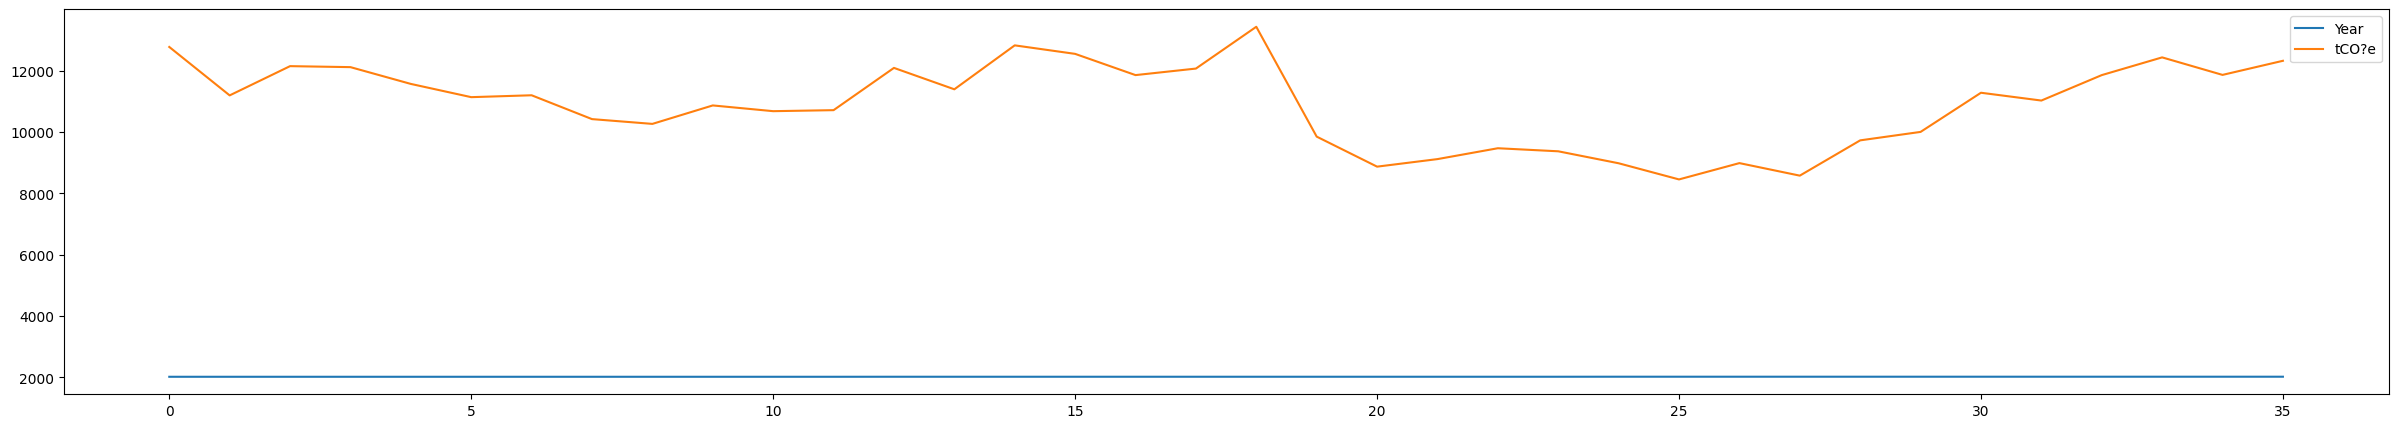

In [44]:
ts_E.plot(figsize=(30,5))

In [45]:
ts_E['Date'] = pd.to_datetime(ts_E['lable'], format='%b %Y')
ts_E.set_index('Date', inplace=True)
ts_E.sort_index(inplace=True)
ts_E

,Year,Period,tCO?e,lable
Date,,,,
2023-01-01,2023,Jan,12766.86,Jan 2023
2023-02-01,2023,Feb,11189.23,Feb 2023
2023-03-01,2023,Mar,12141.88,Mar 2023
2023-04-01,2023,Apr,12109.68,Apr 2023
2023-05-01,2023,May,11562.89,May 2023
2023-06-01,2023,Jun,11131.65,Jun 2023
2023-07-01,2023,Jul,11193.03,Jul 2023
2023-08-01,2023,Aug,10416.40,Aug 2023
2023-09-01,2023,Sep,10260.93,Sep 2023


In [46]:
ts = ts_E['tCO?e'] ## creating the time series variabe

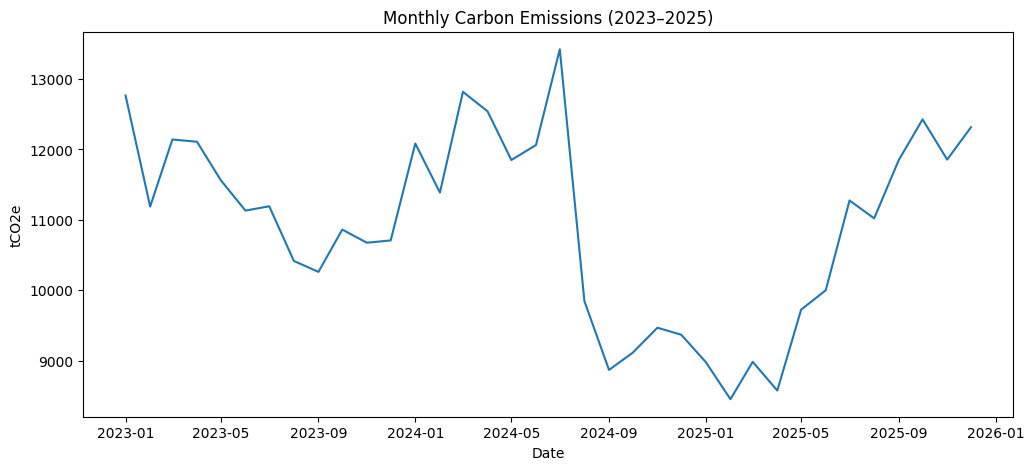

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(ts)

plt.title('Monthly Carbon Emissions (2023–2025)')
plt.ylabel('tCO2e')
plt.xlabel('Date')

plt.show()

In [48]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)
result
#print('ADF Statistic:', result)
#print('p-value:', result[1]) # the time series is non stationary since pvau is greater than 0.5 hence for ARIMA(p,d,q).. we difference to mae it stationary

(np.float64(-2.289642494010456),
 np.float64(0.17533023633464134),
 0,
 35,
 {'1%': np.float64(-3.6327426647230316),
  '5%': np.float64(-2.9485102040816327),
  '10%': np.float64(-2.6130173469387756)},
 np.float64(418.9334425768164))

In [64]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp_add = seasonal_decompose(ts, model='additive', period=12)

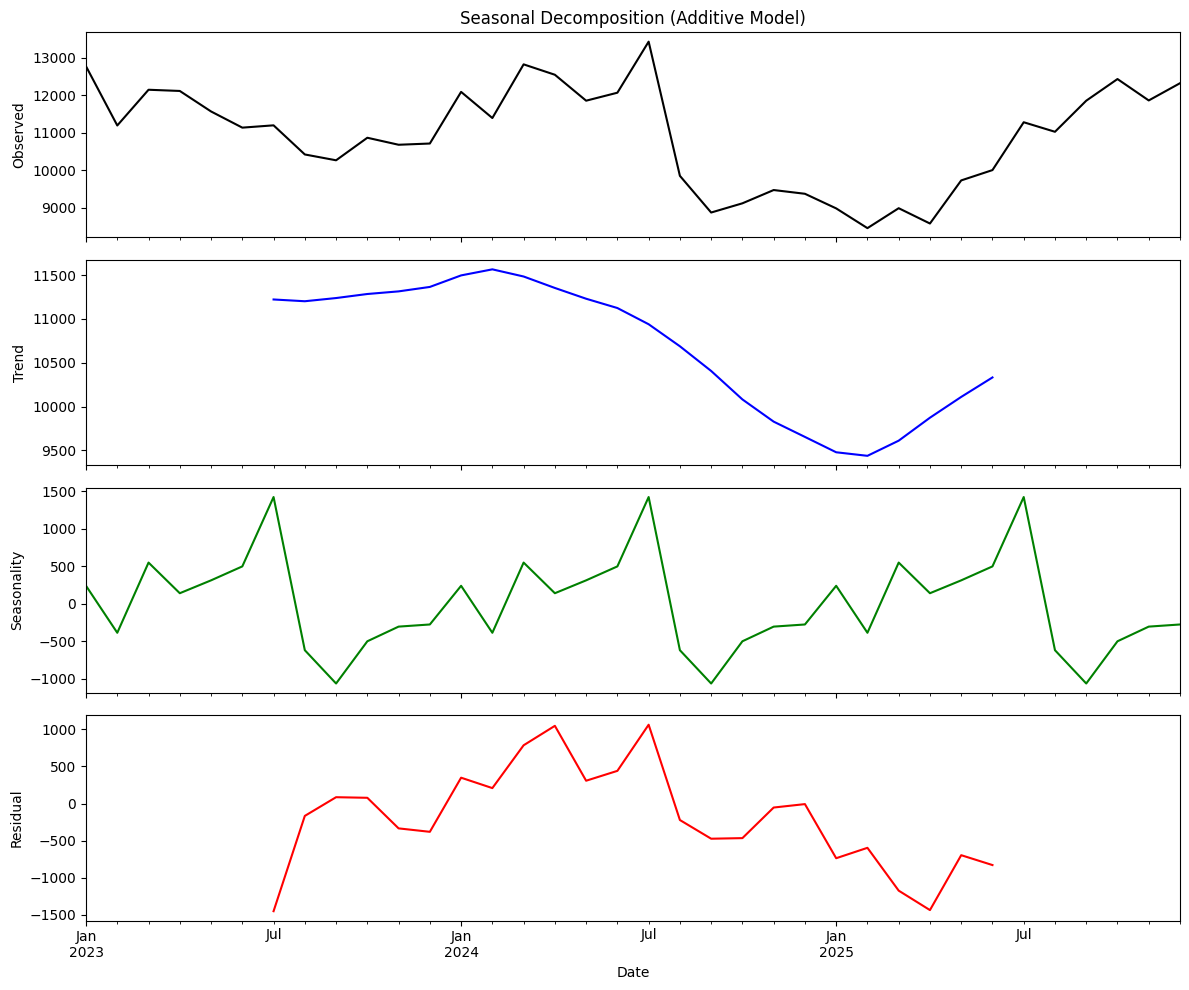


Seasonal Indices (Monthly):
  Jan: +238.28 tCO₂e
  Feb: -387.77 tCO₂e
  Mar: +547.85 tCO₂e
  Apr: +139.49 tCO₂e
  May: +311.09 tCO₂e
  Jun: +496.99 tCO₂e
  Jul: +1421.51 tCO₂e
  Aug: -619.90 tCO₂e
  Sep: -1063.86 tCO₂e
  Oct: -501.04 tCO₂e
  Nov: -305.57 tCO₂e
  Dec: -277.07 tCO₂e


In [65]:


fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomp_add.observed.plot(ax=axes[0], color='black')
axes[0].set_ylabel('Observed')
axes[0].set_title('Seasonal Decomposition (Additive Model)')

decomp_add.trend.plot(ax=axes[1], color='blue')
axes[1].set_ylabel('Trend')

decomp_add.seasonal.plot(ax=axes[2], color='green')
axes[2].set_ylabel('Seasonality')

decomp_add.resid.plot(ax=axes[3], color='red')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.savefig('seasonal_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Print seasonal indices ---
print("\nSeasonal Indices (Monthly):")
seasonal_indices = decomp_add.seasonal.groupby(decomp_add.seasonal.index.month).mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
for m, name in zip(seasonal_indices.index, month_names):
    print(f"  {name}: {seasonal_indices[m]:+.2f} tCO₂e")

In [49]:
ts_diff = ts.diff().dropna()
result_diff = adfuller(ts_diff)

print('ADF Statistic:', result_diff[0])
print('p-value:', result_diff[1]) # p-value < 0.05 → stationary


ADF Statistic: -7.076093110731487
p-value: 4.797825537949282e-10


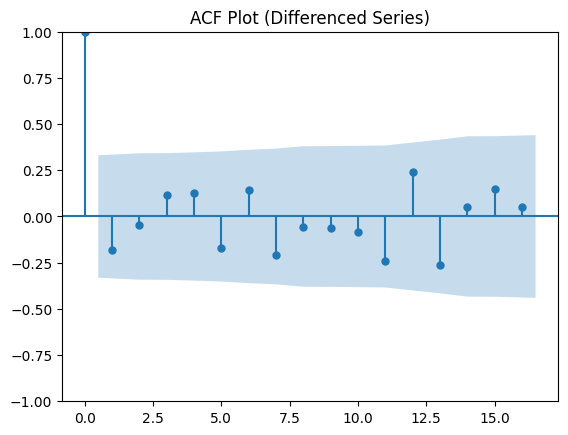

In [50]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(ts.diff().dropna())
plt.title("ACF Plot (Differenced Series)")
plt.show()

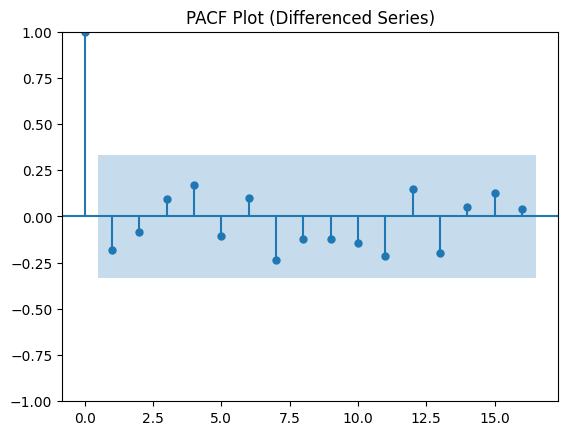

In [51]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(ts.diff().dropna())
plt.title("PACF Plot (Differenced Series)")
plt.show()

The second-order ADF test confirmed stationarity after first differencing, indicating that the emissions series is integrated of order one (I(1)). This validates the use of ARIMA modeling for forecasting.

In [52]:
from statsmodels.tsa.arima.model import ARIMA

# ensure clean series

model = ARIMA(ts, order=(1,1,1)) ##  fitting arima
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  tCO?e   No. Observations:                   36
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -287.501
Date:                Thu, 11 Jun 2026   AIC                            581.002
Time:                        22:08:08   BIC                            585.668
Sample:                    01-01-2023   HQIC                           582.613
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2769      0.837     -0.331      0.741      -1.917       1.363
ma.L1          0.0575      0.897      0.064      0.949      -1.700       1.815
sigma2      8.692e+05   1.59e+05      5.464      0.0

C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [53]:
## CANDIDATE ESTIMATION

model1 = ARIMA(ts, order=(0,1,0)) ##  fitting arima
model1_fit = model1.fit()

print(model1_fit.summary())

C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  tCO?e   No. Observations:                   36
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -289.464
Date:                Thu, 11 Jun 2026   AIC                            580.929
Time:                        22:08:08   BIC                            582.484
Sample:                    01-01-2023   HQIC                           581.466
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       8.93e+05   1.25e+05      7.117      0.000    6.47e+05    1.14e+06
Ljung-Box (L1) (Q):                   1.25   Jarque-Bera (JB):                29.52
Prob(Q):                              0.26   Pr

In [78]:

model2= ARIMA(ts, order=(1,1,0)) ##  fitting arima
model2_fit = model2.fit()

print(model2_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  tCO?e   No. Observations:                   36
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -287.462
Date:                Thu, 11 Jun 2026   AIC                            578.923
Time:                        22:55:44   BIC                            582.034
Sample:                    01-01-2023   HQIC                           579.997
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2266      0.106     -2.146      0.032      -0.434      -0.020
sigma2       8.16e+05   1.29e+05      6.338      0.000    5.64e+05    1.07e+06
Ljung-Box (L1) (Q):                   0.11   Jarque-

C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [61]:

model3  = ARIMA(ts, order=(0,1,1)) ##  fitting arima
model3_fit = model3.fit()

print(model3_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  tCO?e   No. Observations:                   36
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -287.663
Date:                Thu, 11 Jun 2026   AIC                            579.326
Time:                        22:09:51   BIC                            582.436
Sample:                    01-01-2023   HQIC                           580.400
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2074      0.124     -1.672      0.094      -0.450       0.036
sigma2      8.139e+05   1.34e+05      6.080      0.000    5.52e+05    1.08e+06
Ljung-Box (L1) (Q):                   0.05   Jarque-

C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


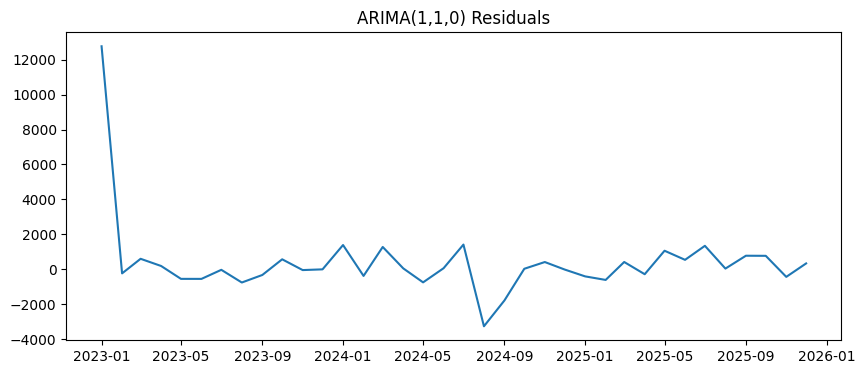

In [108]:
residuals = model2_fit.resid ### checing for residuals

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("ARIMA(1,1,0) Residuals")
plt.show()

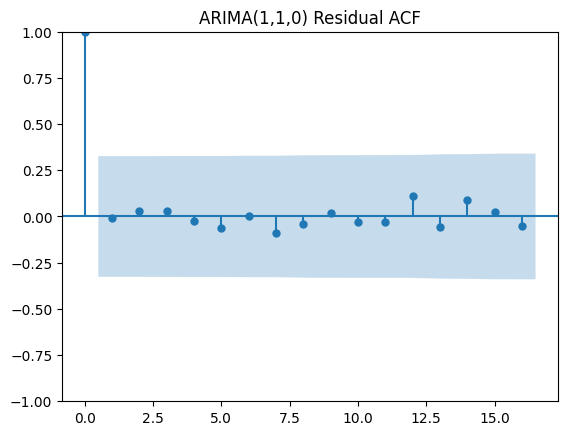

In [110]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals)
plt.title("ARIMA(1,1,0) Residual ACF")
plt.show()

In [87]:
forecast = model2_fit.forecast(steps=12)
print(forecast)

2026-01-01    12212.091804
2026-02-01    12235.687048
2026-03-01    12230.339898
2026-04-01    12231.551668
2026-05-01    12231.277057
2026-06-01    12231.339289
2026-07-01    12231.325186
2026-08-01    12231.328382
2026-09-01    12231.327658
2026-10-01    12231.327822
2026-11-01    12231.327785
2026-12-01    12231.327794
Freq: MS, Name: predicted_mean, dtype: float64


In [103]:
forecast2 = model2_fit.forecast(steps=12)
print(forecast2)

2026-01-01    12212.091804
2026-02-01    12235.687048
2026-03-01    12230.339898
2026-04-01    12231.551668
2026-05-01    12231.277057
2026-06-01    12231.339289
2026-07-01    12231.325186
2026-08-01    12231.328382
2026-09-01    12231.327658
2026-10-01    12231.327822
2026-11-01    12231.327785
2026-12-01    12231.327794
Freq: MS, Name: predicted_mean, dtype: float64


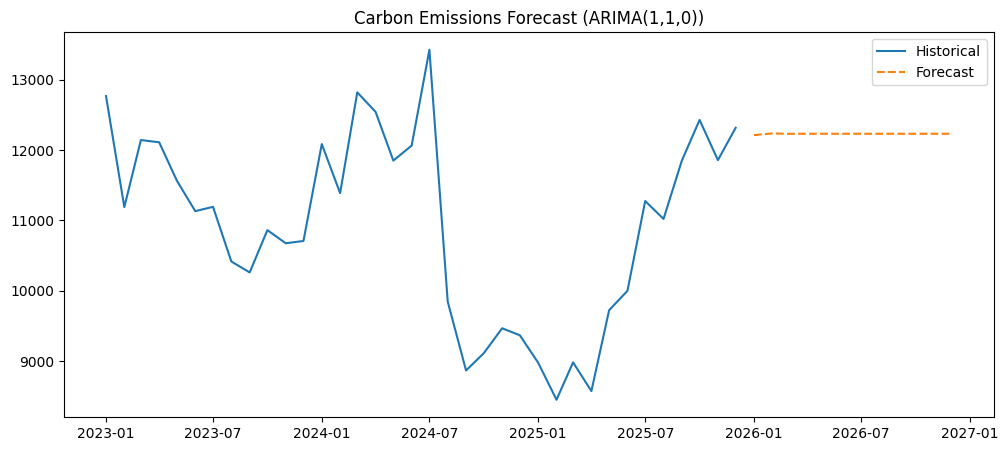

In [107]:
plt.figure(figsize=(12,5))

plt.plot(ts, label='Historical')
plt.plot(forecast2, label='Forecast', linestyle='--')

plt.title("Carbon Emissions Forecast (ARIMA(1,1,0))")
plt.legend()
plt.show()


In [111]:
# --- Get forecast object with confidence intervals ---
forecast_object = model2_fit.get_forecast(steps=12)

# --- Extract mean forecast ---
forecast_mean = forecast_object.predicted_mean

# --- Extract 95% confidence intervals ---
forecast_ci = forecast_object.conf_int(alpha=0.05)

print(forecast_ci)

             lower tCO?e   upper tCO?e
2026-01-01  10441.555459  13982.628148
2026-02-01   9997.434307  14473.939788
2026-03-01   9557.881033  14902.798764
2026-04-01   9196.005166  15267.098171
2026-05-01   8869.653050  15592.901064
2026-06-01   8573.001743  15889.676836
2026-07-01   8298.508951  16164.141422
2026-08-01   8041.997102  16420.659663
2026-09-01   7800.302362  16662.352954
2026-10-01   7571.127643  16891.528002
2026-11-01   7352.706251  17109.949319
2026-12-01   7143.653470  17319.002117


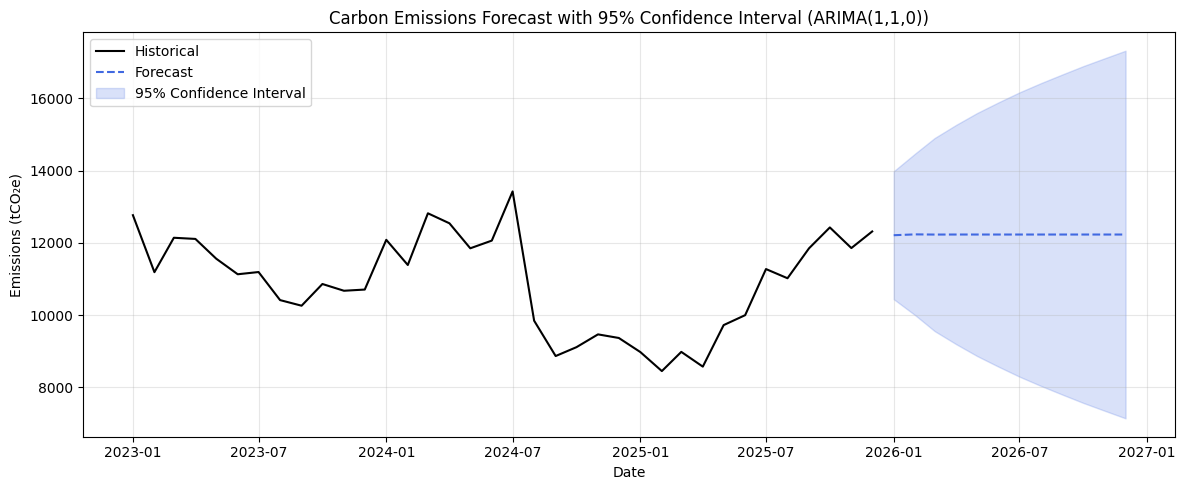

In [112]:
plt.figure(figsize=(12, 5))

# Historical
plt.plot(ts, label='Historical', color='black')

# Point forecast
plt.plot(forecast_mean, label='Forecast', linestyle='--', color='royalblue')

# 95% confidence band
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],   # lower bound
                 forecast_ci.iloc[:, 1],   # upper bound
                 color='royalblue', alpha=0.2, label='95% Confidence Interval')

plt.title('Carbon Emissions Forecast with 95% Confidence Interval (ARIMA(1,1,0))')
plt.xlabel('Date')
plt.ylabel('Emissions (tCO₂e)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [113]:
### CONFIDENCE INTERVAL


from statsmodels.tsa.arima.model import ARIMA
import matplotlib.patches as mpatches

PREDICTIVE PERFORMANCE

In [114]:
# --- Train/Test Split ---
train = ts[:-8]   # Jan 2023 – Apr 2025 (28 months)
test  = ts[-8:]   # May 2025 – Dec 2025 (8 months)

print(f"Training size: {len(train)} months")
print(f"Testing size:  {len(test)} months")
print(f"\nTest period:\n{test}")

Training size: 28 months
Testing size:  8 months

Test period:
Date
2025-05-01     9724.38
2025-06-01     9999.66
2025-07-01    11275.43
2025-08-01    11021.19
2025-09-01    11849.84
2025-10-01    12427.47
2025-11-01    11856.77
2025-12-01    12316.21
Name: tCO?e, dtype: float64


In [119]:
from statsmodels.tsa.arima.model import ARIMA

# --- Fit ARIMA(1,1,0) on TRAINING data only ---
model_train = ARIMA(train, order=(1, 1, 0))
model_train_fit = model_train.fit()

print(model_train_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  tCO?e   No. Observations:                   28
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -222.770
Date:                Fri, 12 Jun 2026   AIC                            449.539
Time:                        00:13:45   BIC                            452.131
Sample:                    01-01-2023   HQIC                           450.310
                         - 04-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2304      0.117     -1.974      0.048      -0.459      -0.002
sigma2      8.886e+05   1.55e+05      5.733      0.000    5.85e+05    1.19e+06
Ljung-Box (L1) (Q):                   0.00   Jarque-

C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL User\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [120]:
# --- Forecast 8 steps ahead (May 2025 – Dec 2025) ---
forecast_test = model_train_fit.get_forecast(steps=8)

# --- Extract forecast mean ---
forecast_mean = forecast_test.predicted_mean

# --- Assign test index so dates align ---
forecast_mean.index = test.index

print("Actual vs Forecasted:")
print(pd.DataFrame({
    'Actual':    test.values,
    'Forecast':  forecast_mean.values,
    'Difference': test.values - forecast_mean.values
}, index=test.index))

Actual vs Forecasted:
              Actual     Forecast   Difference
Date                                          
2025-05-01   9724.38  8669.077882  1055.302118
2025-06-01   9999.66  8647.400886  1352.259114
2025-07-01  11275.43  8652.396132  2623.033868
2025-08-01  11021.19  8651.245028  2369.944972
2025-09-01  11849.84  8651.510288  3198.329712
2025-10-01  12427.47  8651.449162  3776.020838
2025-11-01  11856.77  8651.463248  3205.306752
2025-12-01  12316.21  8651.460002  3664.749998


In [121]:
import numpy as np

actual   = test.values
forecast = forecast_mean.values

# --- RMSE: Root Mean Squared Error ---
rmse = np.sqrt(np.mean((actual - forecast) ** 2))

# --- MAE: Mean Absolute Error ---
mae = np.mean(np.abs(actual - forecast))

# --- MAPE: Mean Absolute Percentage Error ---
mape = np.mean(np.abs((actual - forecast) / actual)) * 100

print("=" * 40)
print("   Forecast Accuracy Metrics")
print("=" * 40)
print(f"  RMSE : {rmse:,.2f} tCO₂e")
print(f"  MAE  : {mae:,.2f} tCO₂e")
print(f"  MAPE : {mape:.2f}%")
print("=" * 40)

   Forecast Accuracy Metrics
  RMSE : 2,820.27 tCO₂e
  MAE  : 2,655.62 tCO₂e
  MAPE : 22.91%
